# 🧹 Project 4: Data Cleaning & Preprocessing Pipeline
**Domain:** Healthcare & Nutritional Analytics  
**Internship Track:** Data Analytics Internship (Oasis Infobyte)  
**Author:** Akshay Anil Kumar  

---

### 📝 Project Overview
This project focuses on building a data cleaning pipeline using the McDonald's Nutrition dataset (`menu.csv`). Raw real-world datasets often contain structural errors, missing data, duplicate entries, or extreme outliers that can distort machine learning models or business reports. 

![Data Pipeline Diagram](images/pipeline-diagram.png)

### 🛠️ Core Pipeline Tasks
* Check dataset dimensions and examine data distributions.
* Detect and handle missing values or duplicate records safely.
* Clean and standardize textual data formats (removing whitespace/hidden characters).
* Use statistical visualizations (Box Plots) to isolate numerical anomalies and outliers.

🚀 Launching Data Cleaning Pipeline...
📊 Initial Shape: 260 rows, 24 columns
🔍 Missing Values Found: 0
🔍 Duplicate Rows Found: 0
-> Cleaned text formatting across string categories.

📈 Statistical summary for Calories column:
count     260.000000
mean      368.269231
std       240.269886
min         0.000000
25%       210.000000
50%       340.000000
75%       500.000000
max      1880.000000
Name: Calories, dtype: float64


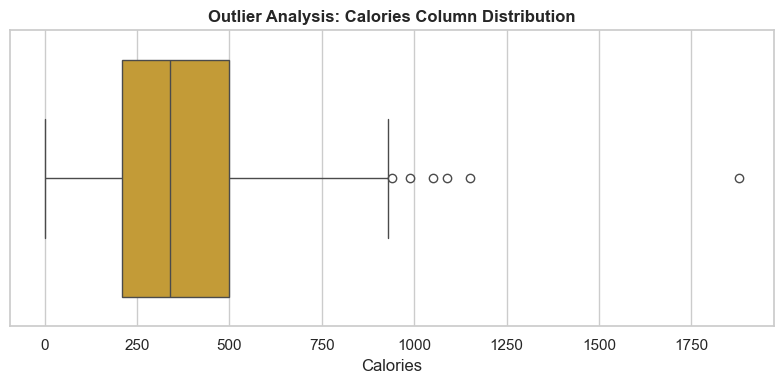


💾 Success! Cleaned dataset exported as 'cleaned_menu_dataset.csv'


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
print("🚀 Launching Data Cleaning Pipeline...")
df = pd.read_csv("menu.csv")
print(f"📊 Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ==========================================
# 2. HANDLE MISSING VALUES & DUPLICATES
# ==========================================
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"🔍 Missing Values Found: {missing_count}")
print(f"🔍 Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("-> Successfully dropped duplicate records.")

# ==========================================
# 3. TEXT STANDARDIZATION
# ==========================================
# Strip trailing spaces from all text columns
text_cols = df.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
print("-> Cleaned text formatting across string categories.")

# ==========================================
# 4. OUTLIER DETECTION (BOX PLOT)
# ==========================================
if 'Calories' in df.columns:
    print("\n📈 Statistical summary for Calories column:")
    print(df['Calories'].describe())
    
    # Render Box Plot to find outliers
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df['Calories'], color='goldenrod')
    plt.title('Outlier Analysis: Calories Column Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Calories')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXPORT THE CLEANED FILE
# ==========================================
df.to_csv("cleaned_menu_dataset.csv", index=False)
print("\n💾 Success! Cleaned dataset exported as 'cleaned_menu_dataset.csv'")